In [14]:
import torch
import os
import torch
import cv2
import matplotlib.pyplot as plt
import numpy as np
import torch.utils.data
import pandas as pd
from sklearn.model_selection import train_test_split
import shutil
import torchvision
from torchvision.transforms import (
    Compose,
    Lambda,
    RandomCrop,
    RandomHorizontalFlip,
    CenterCrop
)
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms
import cv2
from torch.utils.data import Dataset, DataLoader
from PIL import Image

In [15]:
class FlowDatensatz(Dataset):
    """Optical flow dataset. Each clip becomes 16 flow frames (fx, fy, magnitude)
    which are background-invariant and domain-invariant."""

    def __init__(self, df, label_map, augment=False):
        self.df        = list(zip(df['path'], df['label']))
        self.label_map = label_map
        self.augment   = augment
        self.num_frames = 16
        self.load_size  = 128   # load larger, then crop to 112
        self.crop_size  = 112

    def __len__(self):
        return len(self.df)

    def __getitem__(self, index):
        video_path, label_str = self.df[index]
        flow_tensor = self._read(video_path)
        return flow_tensor, torch.tensor(self.label_map[label_str], dtype=torch.long)

    def _read(self, video_path):
        cap   = cv2.VideoCapture(video_path)
        total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        # num_frames+1 raw frames → num_frames flow pairs
        indices = np.linspace(0, total - 1, self.num_frames + 1, dtype=int)

        raw = []
        for i in indices:
            cap.set(cv2.CAP_PROP_POS_FRAMES, i)
            ret, frame = cap.read()
            if not ret:
                frame = raw[-1].copy() if raw else np.zeros(
                    (self.load_size, self.load_size, 3), dtype=np.uint8)
            raw.append(cv2.resize(frame, (self.load_size, self.load_size)))
        cap.release()

        # Decide crop window and flip once for the whole clip
        if self.augment:
            ci   = np.random.randint(0, self.load_size - self.crop_size + 1)
            cj   = np.random.randint(0, self.load_size - self.crop_size + 1)
            flip = np.random.random() < 0.5
        else:
            ci = cj = (self.load_size - self.crop_size) // 2
            flip    = False

        flow_frames = []
        for t in range(self.num_frames):
            g1 = cv2.cvtColor(raw[t],   cv2.COLOR_BGR2GRAY).astype(np.float32)
            g2 = cv2.cvtColor(raw[t+1], cv2.COLOR_BGR2GRAY).astype(np.float32)
            flow = cv2.calcOpticalFlowFarneback(
                g1, g2, None,
                pyr_scale=0.5, levels=3, winsize=15,
                iterations=3, poly_n=5, poly_sigma=1.2, flags=0
            )  # (H, W, 2)

            flow = flow[ci:ci + self.crop_size, cj:cj + self.crop_size]

            if flip:
                flow = flow[:, ::-1, :].copy()
                flow[..., 0] *= -1   # negate horizontal component on horizontal flip

            fx, fy = flow[..., 0], flow[..., 1]
            mag    = np.sqrt(fx**2 + fy**2)
            scale  = mag.max() + 1e-6

            # Encode as 3 channels, all in [0, 1]
            ch = np.stack([
                np.clip(fx / scale * 0.5 + 0.5, 0, 1),  # horizontal flow
                np.clip(fy / scale * 0.5 + 0.5, 0, 1),  # vertical flow
                np.clip(mag / scale,             0, 1),  # magnitude
            ], axis=0).astype(np.float32)

            flow_frames.append(torch.from_numpy(ch))

        return torch.stack(flow_frames)   # (T, 3, H, W)

In [16]:
label_map = {
    "geste_0": 0,
    "geste_1" :1,
    "geste_2": 2,
    "class_1": 3,
    "class_2": 4,
    "Gesture01":5,
    "Gesture02":6,
    "hand_turn":7,
    "ok_sign":8,
    "thumb_up":9
}

In [17]:
df = pd.read_csv("train.csv")

## Data Exploration

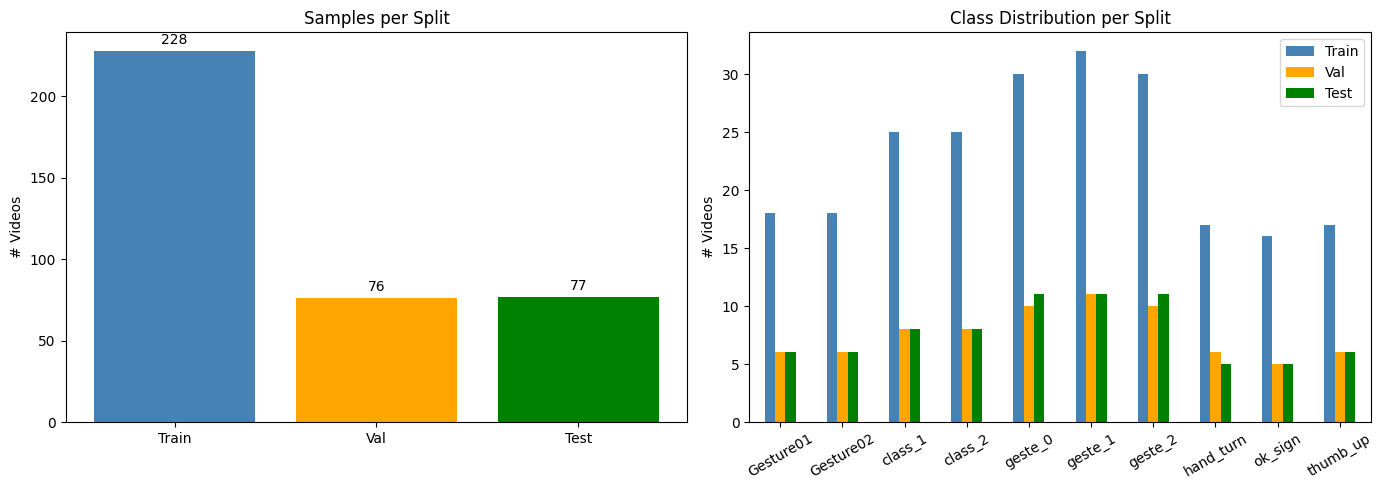

Total videos: 381  |  Classes: 10
Most common: geste_1 (32)  |  Least common: ok_sign (16)


In [18]:
# ── Split sizes + class distribution ─────────────────────────────────────────
val_df  = pd.read_csv("val.csv")
test_df = pd.read_csv("test.csv")
all_df  = pd.concat([df, val_df, test_df])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: split sizes
split_sizes = {"Train": len(df), "Val": len(val_df), "Test": len(test_df)}
bars = axes[0].bar(split_sizes.keys(), split_sizes.values(), color=["steelblue", "orange", "green"])
axes[0].bar_label(bars, padding=3)
axes[0].set_title("Samples per Split")
axes[0].set_ylabel("# Videos")

# Right: class distribution across splits
class_counts = pd.DataFrame({
    "Train": df["label"].value_counts(),
    "Val":   val_df["label"].value_counts(),
    "Test":  test_df["label"].value_counts(),
}).fillna(0).astype(int)
class_counts.plot(kind="bar", ax=axes[1], color=["steelblue", "orange", "green"])
axes[1].set_title("Class Distribution per Split")
axes[1].set_ylabel("# Videos")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=30)
axes[1].legend(loc="upper right")

plt.tight_layout()
plt.show()

print(f"Total videos: {len(all_df)}  |  Classes: {all_df['label'].nunique()}")
print(f"Most common: {df['label'].value_counts().idxmax()} ({df['label'].value_counts().max()})"
      f"  |  Least common: {df['label'].value_counts().idxmin()} ({df['label'].value_counts().min()})")

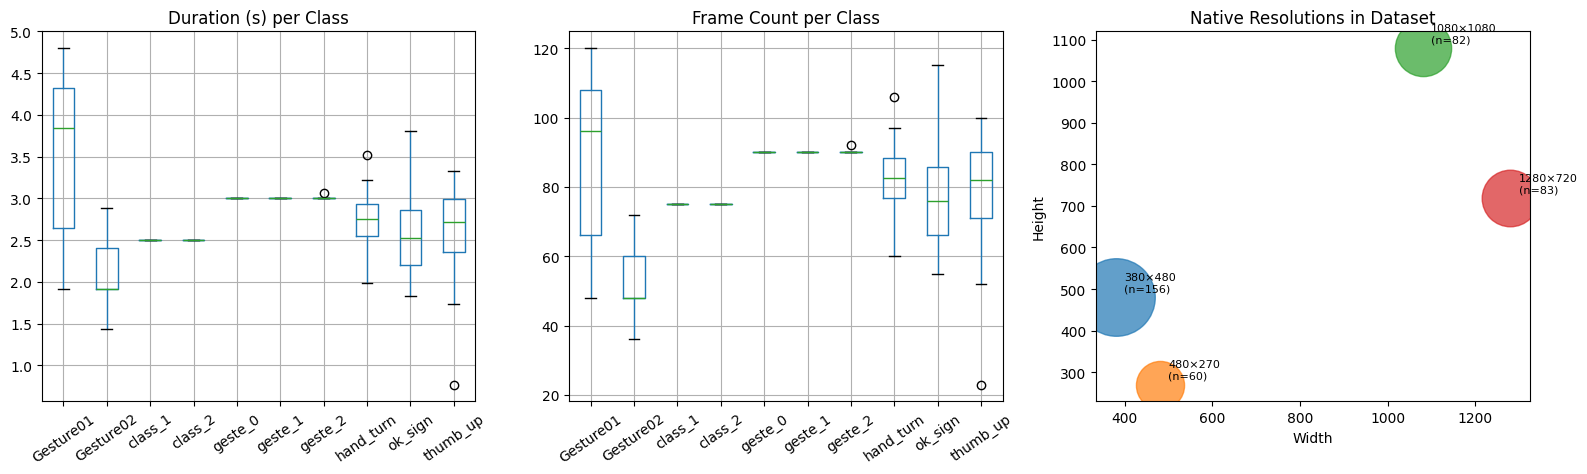

In [19]:
# ── Video metadata: resolution, duration, FPS per class ──────────────────────
meta = []
for _, row in all_df.iterrows():
    cap = cv2.VideoCapture(row["path"])
    fps = cap.get(cv2.CAP_PROP_FPS)
    n   = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    w   = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    h   = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    cap.release()
    meta.append({"label": row["label"], "fps": fps, "frames": n,
                 "duration": n / fps if fps > 0 else 0, "w": w, "h": h})

meta_df = pd.DataFrame(meta)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Duration box per class
meta_df.boxplot(column="duration", by="label", ax=axes[0])
axes[0].set_title("Duration (s) per Class")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=35)
plt.sca(axes[0]); plt.title("Duration (s) per Class")

# Frame count box per class
meta_df.boxplot(column="frames", by="label", ax=axes[1])
axes[1].set_title("Frame Count per Class")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=35)
plt.sca(axes[1]); plt.title("Frame Count per Class")

# Resolution scatter (unique w×h per source)
res_counts = meta_df.groupby(["w", "h"]).size().reset_index(name="count")
for _, r in res_counts.iterrows():
    axes[2].scatter(r["w"], r["h"], s=r["count"] * 20, alpha=0.7)
    axes[2].annotate(f'{int(r["w"])}×{int(r["h"])}\n(n={int(r["count"])})',
                     (r["w"], r["h"]), textcoords="offset points", xytext=(6, 4), fontsize=8)
axes[2].set_title("Native Resolutions in Dataset")
axes[2].set_xlabel("Width"); axes[2].set_ylabel("Height")

plt.suptitle("")
plt.tight_layout()
plt.show()

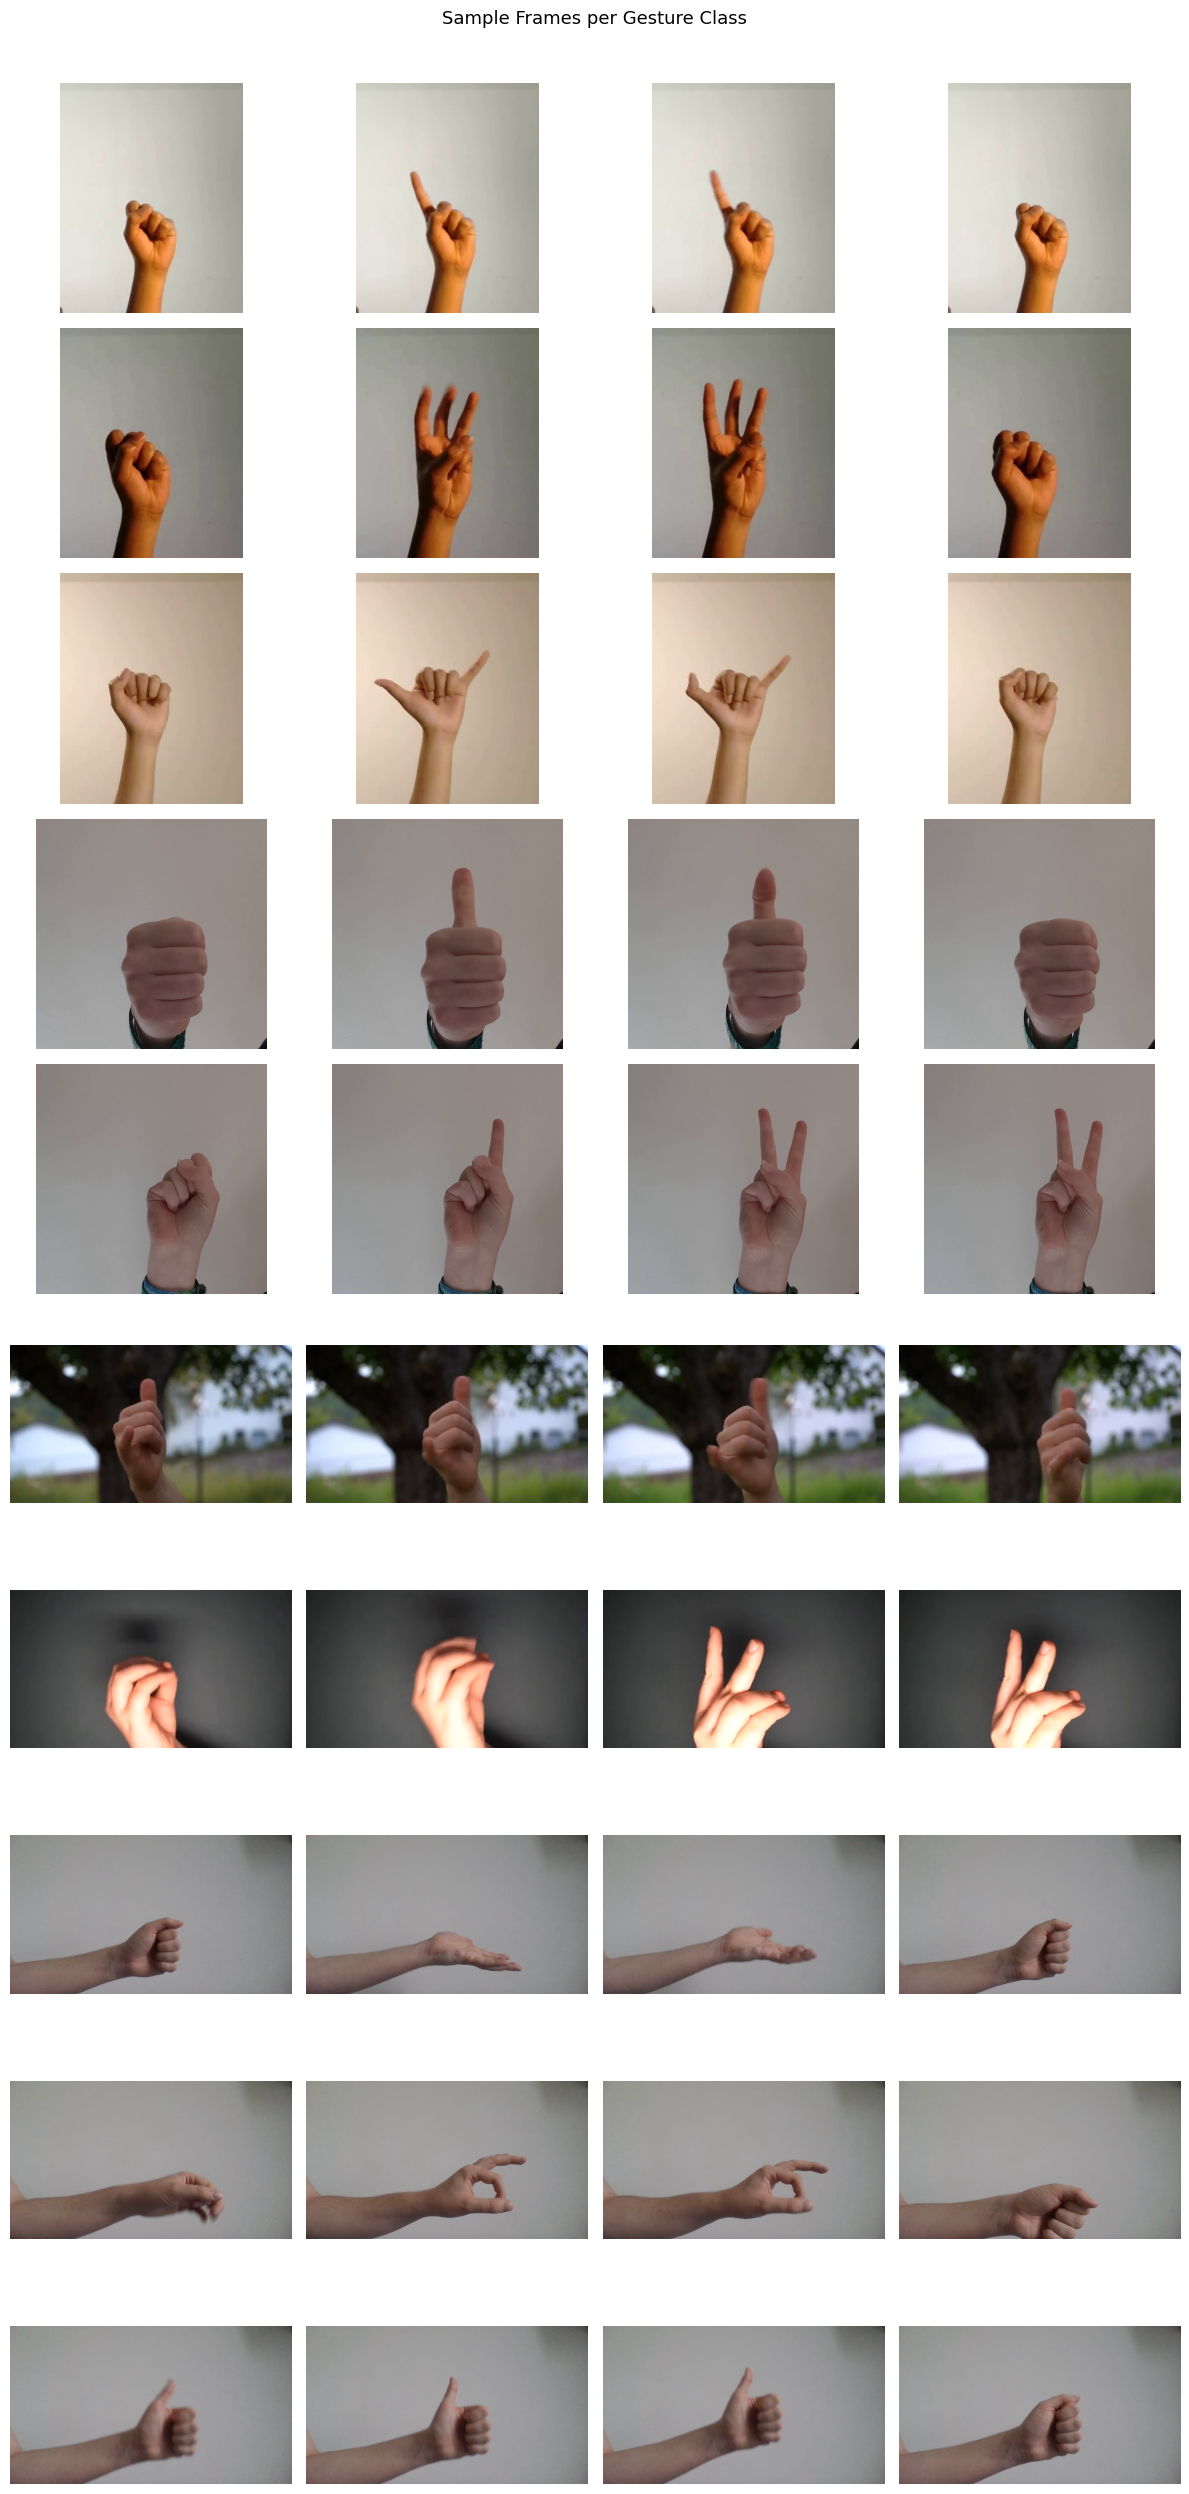

In [20]:
# ── Sample frames from each gesture class ────────────────────────────────────
n_frames_to_show = 4
classes = list(label_map.keys())
fig, axes = plt.subplots(len(classes), n_frames_to_show, figsize=(n_frames_to_show * 3, len(classes) * 2.5))

for row_i, cls in enumerate(classes):
    sample_path = all_df[all_df["label"] == cls]["path"].iloc[0]
    cap = cv2.VideoCapture(sample_path)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    indices = np.linspace(0, total - 1, n_frames_to_show, dtype=int)
    for col_i, frame_idx in enumerate(indices):
        cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
        ret, frame = cap.read()
        ax = axes[row_i][col_i]
        if ret:
            ax.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        else:
            ax.set_facecolor("black")
        ax.axis("off")
        if col_i == 0:
            ax.set_ylabel(cls, fontsize=10, rotation=0, labelpad=60, va="center")
    cap.release()

fig.suptitle("Sample Frames per Gesture Class", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [21]:
# Preprocessing is now baked into FlowDatensatz:
#   - Training:   random 112×112 crop from 128×128 + 50% horizontal flip
#   - Val / Test: centre 112×112 crop, no flip
# No separate transform objects needed.

In [22]:
train_loader = DataLoader(FlowDatensatz(df, label_map), batch_size=16, num_workers=12,shuffle=True, pin_memory=True)

In [23]:
val_df = pd.read_csv("val.csv")
val_loader = DataLoader(FlowDatensatz(val_df, label_map), batch_size=16, num_workers=12,shuffle=True, pin_memory=True)

In [24]:
import math

import torch.nn as nn
from torch.nn.modules.utils import _triple


class SpatioTemporalConv(nn.Module):
    r"""Applies a factored 3D convolution over an input signal composed of several input
    planes with distinct spatial and time axes, by performing a 2D convolution over the
    spatial axes to an intermediate subspace, followed by a 1D convolution over the time
    axis to produce the final output.
    Args:
        in_channels (int): Number of channels in the input tensor
        out_channels (int): Number of channels produced by the convolution
        kernel_size (int or tuple): Size of the convolving kernel
        stride (int or tuple, optional): Stride of the convolution. Default: 1
        padding (int or tuple, optional): Zero-padding added to the sides of the input during their respective convolutions. Default: 0
        bias (bool, optional): If ``True``, adds a learnable bias to the output. Default: ``True``
    """

    def __init__(self, in_channels, out_channels, kernel_size, stride=1, padding=0, bias=False):
        super(SpatioTemporalConv, self).__init__()

        # if ints are entered, convert them to iterables, 1 -> [1, 1, 1]
        kernel_size = _triple(kernel_size)
        stride = _triple(stride)
        padding = _triple(padding)


        self.temporal_spatial_conv = nn.Conv3d(in_channels, out_channels, kernel_size,
                                    stride=stride, padding=padding, bias=bias)
        self.bn = nn.BatchNorm3d(out_channels)
        self.relu = nn.ReLU()


    def forward(self, x):
        x = self.bn(self.temporal_spatial_conv(x))
        x = self.relu(x)
        return x


class SpatioTemporalResBlock(nn.Module):
    r"""Single block for the ResNet network. Uses SpatioTemporalConv in
        the standard ResNet block layout (conv->batchnorm->ReLU->conv->batchnorm->sum->ReLU)

        Args:
            in_channels (int): Number of channels in the input tensor.
            out_channels (int): Number of channels in the output produced by the block.
            kernel_size (int or tuple): Size of the convolving kernels.
            downsample (bool, optional): If ``True``, the output size is to be smaller than the input. Default: ``False``
        """

    def __init__(self, in_channels, out_channels, kernel_size, downsample=False):
        super(SpatioTemporalResBlock, self).__init__()

        # If downsample == True, the first conv of the layer has stride = 2
        # to halve the residual output size, and the input x is passed
        # through a seperate 1x1x1 conv with stride = 2 to also halve it.

        # no pooling layers are used inside ResNet
        self.downsample = downsample

        # to allow for SAME padding
        padding = kernel_size // 2

        if self.downsample:
            # downsample with stride =2 the input x
            self.downsampleconv = SpatioTemporalConv(in_channels, out_channels, 1, stride=2)
            self.downsamplebn = nn.BatchNorm3d(out_channels)

            # downsample with stride = 2when producing the residual
            self.conv1 = SpatioTemporalConv(in_channels, out_channels, kernel_size, padding=padding, stride=2)
        else:
            self.conv1 = SpatioTemporalConv(in_channels, out_channels, kernel_size, padding=padding)

        self.bn1 = nn.BatchNorm3d(out_channels)
        self.relu1 = nn.ReLU()

        # standard conv->batchnorm->ReLU
        self.conv2 = SpatioTemporalConv(out_channels, out_channels, kernel_size, padding=padding)
        self.bn2 = nn.BatchNorm3d(out_channels)
        self.outrelu = nn.ReLU()

    def forward(self, x):
        res = self.relu1(self.bn1(self.conv1(x)))
        res = self.bn2(self.conv2(res))

        if self.downsample:
            x = self.downsamplebn(self.downsampleconv(x))

        return self.outrelu(x + res)


class SpatioTemporalResLayer(nn.Module):
    r"""Forms a single layer of the ResNet network, with a number of repeating
    blocks of same output size stacked on top of each other

        Args:
            in_channels (int): Number of channels in the input tensor.
            out_channels (int): Number of channels in the output produced by the layer.
            kernel_size (int or tuple): Size of the convolving kernels.
            layer_size (int): Number of blocks to be stacked to form the layer
            block_type (Module, optional): Type of block that is to be used to form the layer. Default: SpatioTemporalResBlock.
            downsample (bool, optional): If ``True``, the first block in layer will implement downsampling. Default: ``False``
        """

    def __init__(self, in_channels, out_channels, kernel_size, layer_size, block_type=SpatioTemporalResBlock,
                 downsample=False):

        super(SpatioTemporalResLayer, self).__init__()

        # implement the first block
        self.block1 = block_type(in_channels, out_channels, kernel_size, downsample)

        # prepare module list to hold all (layer_size - 1) blocks
        self.blocks = nn.ModuleList([])
        for i in range(layer_size - 1):
            # all these blocks are identical, and have downsample = False by default
            self.blocks += [block_type(out_channels, out_channels, kernel_size)]

    def forward(self, x):
        x = self.block1(x)
        for block in self.blocks:
            x = block(x)

        return x


class R3DNet(nn.Module):
    r"""Forms the overall ResNet feature extractor by initializng 5 layers, with the number of blocks in
    each layer set by layer_sizes, and by performing a global average pool at the end producing a
    512-dimensional vector for each element in the batch.

        Args:
            layer_sizes (tuple): An iterable containing the number of blocks in each layer
            block_type (Module, optional): Type of block that is to be used to form the layers. Default: SpatioTemporalResBlock.
    """

    def __init__(self, layer_sizes, block_type=SpatioTemporalResBlock):
        super(R3DNet, self).__init__()

        # first conv, with stride 1x2x2 and kernel size 3x7x7
        self.conv1 = SpatioTemporalConv(3, 64, [3, 7, 7], stride=[1, 2, 2], padding=[1, 3, 3])
        # output of conv2 is same size as of conv1, no downsampling needed. kernel_size 3x3x3
        self.conv2 = SpatioTemporalResLayer(64, 64, 3, layer_sizes[0], block_type=block_type)
        # each of the final three layers doubles num_channels, while performing downsampling
        # inside the first block
        self.conv3 = SpatioTemporalResLayer(64, 128, 3, layer_sizes[1], block_type=block_type, downsample=True)
        self.conv4 = SpatioTemporalResLayer(128, 256, 3, layer_sizes[2], block_type=block_type, downsample=True)
        self.conv5 = SpatioTemporalResLayer(256, 512, 3, layer_sizes[3], block_type=block_type, downsample=True)

        # global average pooling of the output
        self.pool = nn.AdaptiveAvgPool3d(1)

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.conv4(x)
        x = self.conv5(x)

        x = self.pool(x)

        return x.view(-1, 512)


class R3DClassifier(nn.Module):
    r"""Forms a complete ResNet classifier producing vectors of size num_classes, by initializng 5 layers,
    with the number of blocks in each layer set by layer_sizes, and by performing a global average pool
    at the end producing a 512-dimensional vector for each element in the batch,
    and passing them through a Linear layer.

        Args:
            num_classes(int): Number of classes in the data
            layer_sizes (tuple): An iterable containing the number of blocks in each layer
            block_type (Module, optional): Type of block that is to be used to form the layers. Default: SpatioTemporalResBlock.
        """

    def __init__(self, num_classes, layer_sizes, block_type=SpatioTemporalResBlock, pretrained=False):
        super(R3DClassifier, self).__init__()

        self.res3d = R3DNet(layer_sizes, block_type)
        self.linear = nn.Linear(512, num_classes)

        self.__init_weight()

        if pretrained:
            self.__load_pretrained_weights()

    def forward(self, x):
        x = self.res3d(x)
        logits = self.linear(x)

        return logits

    def __load_pretrained_weights(self):
        s_dict = self.state_dict()
        for name in s_dict:
            print(name)
            print(s_dict[name].size())

    def __init_weight(self):
        for m in self.modules():
            if isinstance(m, nn.Conv3d):
                nn.init.kaiming_normal_(m.weight)
            elif isinstance(m, nn.BatchNorm3d):
                m.weight.data.fill_(1)
                m.bias.data.zero_()


def get_1x_lr_params(model):
    """
    This generator returns all the parameters for the conv layer of the net.
    """
    b = [model.res3d]
    for i in range(len(b)):
        for k in b[i].parameters():
            if k.requires_grad:
                yield k


def get_10x_lr_params(model):
    """
    This generator returns all the parameters for the fc layer of the net.
    """
    b = [model.linear]
    for j in range(len(b)):
        for k in b[j].parameters():
            if k.requires_grad:
                yield k

if __name__ == "__main__":
    import torch
    inputs = torch.rand(1, 3, 16, 112, 112)
    net = R3DClassifier(101, (2, 2, 2, 2), pretrained=True)

    outputs = net.forward(inputs)
    print(outputs.size())

res3d.conv1.temporal_spatial_conv.weight
torch.Size([64, 3, 3, 7, 7])
res3d.conv1.bn.weight
torch.Size([64])
res3d.conv1.bn.bias
torch.Size([64])
res3d.conv1.bn.running_mean
torch.Size([64])
res3d.conv1.bn.running_var
torch.Size([64])
res3d.conv1.bn.num_batches_tracked
torch.Size([])
res3d.conv2.block1.conv1.temporal_spatial_conv.weight
torch.Size([64, 64, 3, 3, 3])
res3d.conv2.block1.conv1.bn.weight
torch.Size([64])
res3d.conv2.block1.conv1.bn.bias
torch.Size([64])
res3d.conv2.block1.conv1.bn.running_mean
torch.Size([64])
res3d.conv2.block1.conv1.bn.running_var
torch.Size([64])
res3d.conv2.block1.conv1.bn.num_batches_tracked
torch.Size([])
res3d.conv2.block1.bn1.weight
torch.Size([64])
res3d.conv2.block1.bn1.bias
torch.Size([64])
res3d.conv2.block1.bn1.running_mean
torch.Size([64])
res3d.conv2.block1.bn1.running_var
torch.Size([64])
res3d.conv2.block1.bn1.num_batches_tracked
torch.Size([])
res3d.conv2.block1.conv2.temporal_spatial_conv.weight
torch.Size([64, 64, 3, 3, 3])
res3d.conv2.

In [25]:
device = "cuda"
model = R3DClassifier(10, (2, 2, 2, 2)).to(device)
pretrained_optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-3,
    weight_decay=1e-4,
)
pretrained_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    pretrained_optimizer, T_max=50
)
pretrained_criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

In [26]:
best_val_acc_pretrained = 0.0
pretrained_train_accs, pretrained_val_accs = [], []

for epoch in range(1, 51):
    model.train()
    train_loss, train_correct, train_total = 0.0, 0, 0

    for videos, labels in train_loader:
        videos, labels = videos.to(device), labels.to(device)
        pretrained_optimizer.zero_grad(set_to_none=True)
        outputs = model(videos.permute(0,2,1,3,4))
        loss = pretrained_criterion(outputs, labels)
        loss.backward()
        pretrained_optimizer.step()

        train_loss    += loss.item() * videos.size(0)
        train_correct += (outputs.argmax(1) == labels).sum().item()
        train_total   += videos.size(0)

    pretrained_scheduler.step()
    model.eval()
    val_correct, val_total = 0, 0
    with torch.no_grad():
        for videos, labels in val_loader:
            videos, labels = videos.to(device), labels.to(device)
            outputs = model(videos.permute(0,2,1,3,4))
            val_correct += (outputs.argmax(1) == labels).sum().item()
            val_total   += labels.size(0)

    train_acc = train_correct / train_total
    val_acc   = val_correct / val_total * 100
    pretrained_train_accs.append(train_acc * 100)
    pretrained_val_accs.append(val_acc)

    if val_acc > best_val_acc_pretrained:
        best_val_acc_pretrained = val_acc
        torch.save(model.state_dict(), "flow_model.pth")

    if epoch % 10 == 0:
        print(f"Epoch {epoch:3d} | train acc: {train_acc*100:.1f}%  "
              f"val acc: {val_acc:.1f}%  (best: {best_val_acc_pretrained:.1f}%)")


Epoch  10 | train acc: 98.2%  val acc: 89.5%  (best: 90.8%)
Epoch  20 | train acc: 100.0%  val acc: 86.8%  (best: 90.8%)
Epoch  30 | train acc: 100.0%  val acc: 89.5%  (best: 94.7%)
Epoch  40 | train acc: 100.0%  val acc: 94.7%  (best: 94.7%)
Epoch  50 | train acc: 100.0%  val acc: 96.1%  (best: 96.1%)


In [27]:
test_df = pd.read_csv("test.csv")

test_loader = DataLoader(FlowDatensatz(test_df, label_map), batch_size=16, shuffle=True, pin_memory=True, num_workers=12)

In [29]:
model.eval()

test_loss, test_correct, test_total = 0.0, 0, 0

with torch.no_grad():
    for videos, labels in test_loader:
        videos, labels = videos.to(device), labels.to(device)
        outputs = model(videos.permute(0,2,1,3,4))                    # (B, num_classes)
        loss = pretrained_criterion(outputs, labels)
        
        test_loss += loss.item() * videos.size(0)
        preds = outputs.argmax(dim=1)
        # _, predicted = torch.max(outputs, 1)
        test_total += labels.size(0)
        test_correct += (preds == labels).sum().item()

avg_loss = test_loss / test_total
accuracy = (test_correct / test_total)*100

print(accuracy)

93.5064935064935


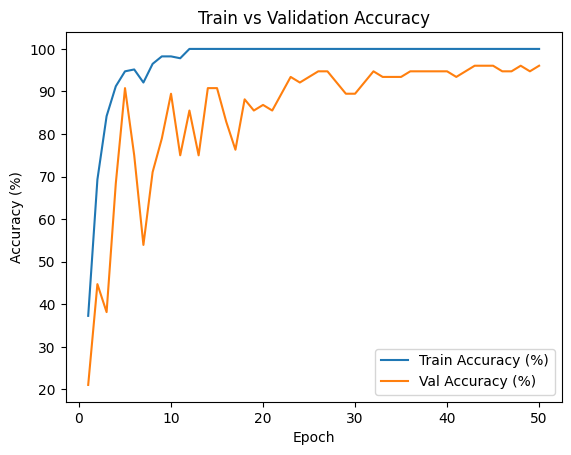

In [30]:
train_accs_pct = [acc * 100 for acc in pretrained_train_accs]  # convert to %

fig, ax = plt.subplots()
ax.plot(range(1, len(pretrained_train_accs) + 1), pretrained_train_accs, label="Train Accuracy (%)")
ax.plot(range(1, len(pretrained_val_accs) + 1), pretrained_val_accs, label="Val Accuracy (%)")
ax.set_xlabel("Epoch")
ax.set_ylabel("Accuracy (%)")
ax.set_title("Train vs Validation Accuracy")
ax.legend()
plt.show()